In [135]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


In [139]:

# Load the dataset
df = pd.read_csv("/content/Train_Test_IoT_Garage_Door.csv")


In [140]:

# Data Exploration and Preprocessing
print("Initial DataFrame:")
print(df.head())



Initial DataFrame:
        date        time door_state sphone_signal  label  type
0  25-Apr-19   14:42:33      closed             0      1  ddos
1  25-Apr-19   14:42:38      closed             0      1  ddos
2  25-Apr-19   14:42:43      closed             0      1  ddos
3  25-Apr-19   14:42:48      closed             0      1  ddos
4  25-Apr-19   14:42:58      closed             0      1  ddos


In [141]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39587 entries, 0 to 39586
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           39587 non-null  object
 1   time           39587 non-null  object
 2   door_state     39587 non-null  object
 3   sphone_signal  39587 non-null  object
 4   label          39587 non-null  int64 
 5   type           39587 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.8+ MB


In [143]:
df['door_state'].unique()

array(['closed', 'open'], dtype=object)

In [144]:
df['door_state']=df['door_state'].map({'closed':0,'open':1})

In [145]:
df['door_state'].value_counts()

,count
door_state,
0,35575
1,4012


In [156]:
df['sphone_signal'].unique()

array(['0', '1', 'true  ', 'false  '], dtype=object)

In [157]:
df['sphone_signal']=df['sphone_signal'].map({'0':0, '1':1, 'true  ':1, 'false  ':0})

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39587 entries, 0 to 39586
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           39587 non-null  object
 1   time           39587 non-null  object
 2   door_state     39587 non-null  int64 
 3   sphone_signal  39587 non-null  int64 
 4   label          39587 non-null  int64 
 5   type           39587 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.8+ MB


In [159]:
df['sphone_signal'].unique()

array([0, 1])

In [160]:
df['type'].unique()

array(['ddos', 'backdoor', 'injection', 'normal', 'password',
       'ransomware', 'xss', 'scanning'], dtype=object)

In [161]:
df['type'].value_counts()

,count
type,
normal,15000
ddos,5000
backdoor,5000
injection,5000
password,5000
ransomware,2902
xss,1156
scanning,529


In [162]:
df

,date,time,door_state,sphone_signal,label,type
0,25-Apr-19,14:42:33,0,0,1,ddos
1,25-Apr-19,14:42:38,0,0,1,ddos
2,25-Apr-19,14:42:43,0,0,1,ddos
3,25-Apr-19,14:42:48,0,0,1,ddos
4,25-Apr-19,14:42:58,0,0,1,ddos
...,...,...,...,...,...,...
39582,28-Apr-19,05:15:19,0,0,1,ransomware
39583,28-Apr-19,05:15:20,0,0,1,ransomware
39584,28-Apr-19,05:15:21,0,0,1,ransomware
39585,28-Apr-19,05:15:21,0,0,1,ransomware


In [163]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Strip spaces from date and time columns
df['date'] = df['date'].astype(str).str.strip()
df['time'] = df['time'].astype(str).str.strip()

# Try parsing with mixed formats automatically
df['datetime'] = pd.to_datetime(
    df['date'] + ' ' + df['time'],
    format='mixed',  # lets pandas handle inconsistent formats
    errors='coerce'  # replaces invalid formats with NaT
)

# Drop rows where datetime couldn't be parsed (if any)
df = df.dropna(subset=['datetime'])

# Drop old columns
df = df.drop(['date', 'time'], axis=1)

# Encode categorical features
categorical_cols = ['type']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    joblib.dump(le, f'{col}_encoder.pkl')



#

print("\n✅ DataFrame after preprocessing:")
display(df.head())



✅ DataFrame after preprocessing:


,door_state,sphone_signal,label,type,datetime
0,0,0,1,1,2019-04-25 14:42:33
1,0,0,1,1,2019-04-25 14:42:38
2,0,0,1,1,2019-04-25 14:42:43
3,0,0,1,1,2019-04-25 14:42:48
4,0,0,1,1,2019-04-25 14:42:58


In [164]:
df.isna().sum()

,0
door_state,0
sphone_signal,0
label,0
type,0
datetime,0


In [165]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils
from collections import Counter


In [166]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

In [167]:
df = df.drop(columns=['datetime'])

In [168]:


# Separate features (X) and target (y)
X = df.drop(columns=["label", "type"])  # Removed 'type' as per your code
y = df["type"]


In [169]:
X

,door_state,sphone_signal,hour,day,month,weekday
0,0,0,14,25,4,3
1,0,0,14,25,4,3
2,0,0,14,25,4,3
3,0,0,14,25,4,3
4,0,0,14,25,4,3
...,...,...,...,...,...,...
39582,0,0,5,28,4,6
39583,0,0,5,28,4,6
39584,0,0,5,28,4,6
39585,0,0,5,28,4,6


In [170]:
X.dtypes

,0
door_state,int64
sphone_signal,int64
hour,int32
day,int32
month,int32
weekday,int32


In [171]:
y.dtypes

dtype('int64')

In [172]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [173]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [174]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

num_classes = len(le.classes_)
input_dim = X_train_scaled.shape[1]

# Handle imbalance
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights = dict(enumerate(class_weights))


model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
mc = callbacks.ModelCheckpoint('network_attack_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[es, mc],
    verbose=2
)

model.save('final_network_model.h5')


Epoch 1/50


109/109 - 3s - 26ms/step - accuracy: 0.7569 - loss: 0.7655 - val_accuracy: 0.5101 - val_loss: 1.5647
Epoch 2/50


109/109 - 1s - 6ms/step - accuracy: 0.9697 - loss: 0.1718 - val_accuracy: 0.4658 - val_loss: 1.2276
Epoch 3/50


109/109 - 1s - 6ms/step - accuracy: 0.9894 - loss: 0.0759 - val_accuracy: 0.6078 - val_loss: 0.7337
Epoch 4/50


109/109 - 1s - 6ms/step - accuracy: 0.9958 - loss: 0.0411 - val_accuracy: 0.9909 - val_loss: 0.2211
Epoch 5/50


...

109/109 - 1s - 6ms/step - accuracy: 0.9999 - loss: 9.2580e-04 - val_accuracy: 1.0000 - val_loss: 1.0881e-05
Epoch 34/50
109/109 - 1s - 11ms/step - accuracy: 0.9999 - loss: 8.7435e-04 - val_accuracy: 1.0000 - val_loss: 1.3900e-05
Epoch 35/50
109/109 - 1s - 6ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 1.3399e-05
Epoch 36/50


109/109 - 1s - 6ms/step - accuracy: 0.9999 - loss: 6.9621e-04 - val_accuracy: 1.0000 - val_loss: 9.5093e-06
Epoch 37/50
109/109 - 1s - 6ms/step - accuracy: 0.9998 - loss: 8.3849e-04 - val_accuracy: 1.0000 - val_loss: 1.3492e-05
Epoch 38/50


109/109 - 2s - 15ms/step - accuracy: 0.9999 - loss: 5.2448e-04 - val_accuracy: 1.0000 - val_loss: 8.1507e-06
Epoch 39/50


109/109 - 1s - 8ms/step - accuracy: 1.0000 - loss: 4.8843e-04 - val_accuracy: 1.0000 - val_loss: 5.3458e-06
Epoch 40/50
109/109 - 1s - 6ms/step - accuracy: 1.0000 - loss: 3.9899e-04 - val_accuracy: 1.0000 - val_loss: 7.0193e-06
Epoch 41/50
109/109 - 1s - 6ms/step - accuracy: 1.0000 - loss: 5.0161e-04 - val_accuracy: 1.0000 - val_loss: 9.1516e-06
Epoch 42/50


109/109 - 1s - 6ms/step - accuracy: 0.9999 - loss: 6.2471e-04 - val_accuracy: 1.0000 - val_loss: 4.0185e-06
Epoch 43/50
109/109 - 1s - 5ms/step - accuracy: 1.0000 - loss: 4.8142e-04 - val_accuracy: 1.0000 - val_loss: 5.3643e-05
Epoch 44/50
109/109 - 1s - 6ms/step - accuracy: 0.9992 - loss: 0.0035 - val_accuracy: 0.9877 - val_loss: 0.0523
Epoch 45/50
109/109 - 1s - 6ms/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 7.5977e-06
Epoch 46/50
109/109 - 1s - 6ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 1.2733e-05
Epoch 47/50
109/109 - 1s - 5ms/step - accuracy: 1.0000 - loss: 8.6548e-04 - val_accuracy: 1.0000 - val_loss: 9.5207e-06
Epoch 48/50
109/109 - 1s - 6ms/step - accuracy: 0.9999 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 6.6888e-06


186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<Figure size 1000x800 with 0 Axes>

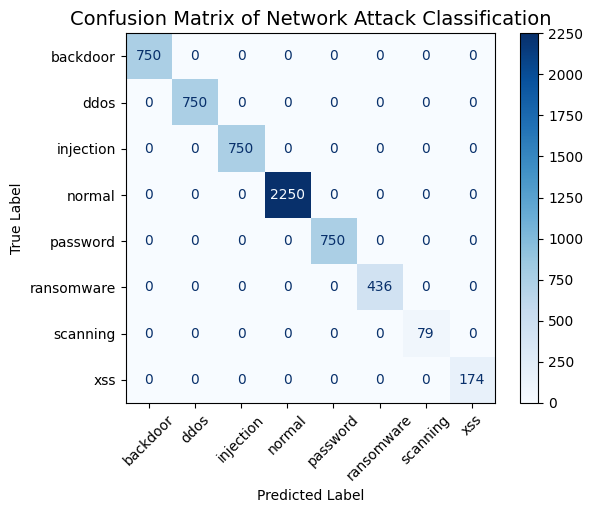


Classification Report:

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00       750
        ddos       1.00      1.00      1.00       750
   injection       1.00      1.00      1.00       750
      normal       1.00      1.00      1.00      2250
    password       1.00      1.00      1.00       750
  ransomware       1.00      1.00      1.00       436
    scanning       1.00      1.00      1.00        79
         xss       1.00      1.00      1.00       174

    accuracy                           1.00      5939
   macro avg       1.00      1.00      1.00      5939
weighted avg       1.00      1.00      1.00      5939



In [175]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict on test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Plot as heatmap
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d', colorbar=True)
plt.title("Confusion Matrix of Network Attack Classification", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

# Optionally print detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


In [180]:
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

def predict_attack_type(new_data):
    """
    Predicts the network attack type for new data.

    Args:
        new_data (dict): A dictionary containing the new data with keys:
                         'door_state', 'sphone_signal', 'hour',
                         'day', 'month', 'weekday'.

    Returns:
        str: The predicted network attack type.
    """
    # Load the scaler and model
    scaler = joblib.load('scaler.pkl')
    model = tf.keras.models.load_model('final_network_model.h5')
    le = joblib.load('type_encoder.pkl')


    # Create a DataFrame from the new data
    new_df = pd.DataFrame([new_data])

    # Preprocess the new data
    # Scale numerical features - Assuming door_state, sphone_signal, hour, day, month, weekday might need scaling depending on the original scaling
    # Based on the notebook, door_state and sphone_signal are already encoded as 0/1. Hour, day, month, weekday were extracted.
    # Re-applying the original scaler to these features.
    features = ['door_state', 'sphone_signal', 'hour', 'day', 'month', 'weekday']
    new_data_scaled = scaler.transform(new_df[features])


    # Make prediction
    prediction_probs = model.predict(new_data_scaled)
    predicted_class_index = np.argmax(prediction_probs, axis=1)[0]

    # Decode the predicted class
    predicted_attack_type = le.inverse_transform([predicted_class_index])[0]

    return predicted_attack_type

# Example usage:
new_sample = {'door_state': 1, 'sphone_signal': 1, 'hour': 20, 'day': 1, 'month': 4, 'weekday': 0}
predicted_type = predict_attack_type(new_sample)
print(f"The predicted attack type is: {predicted_type}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
The predicted attack type is: normal


In [179]:
df[df['type']==3]

,door_state,sphone_signal,label,type,hour,day,month,weekday
8373,1,1,0,3,20,1,4,0
8374,0,0,0,3,20,1,4,0
8375,1,1,0,3,20,1,4,0
8376,0,0,0,3,20,1,4,0
8377,1,1,0,3,20,1,4,0
...,...,...,...,...,...,...,...,...
29995,0,0,0,3,12,31,3,6
29996,1,1,0,3,12,31,3,6
29997,0,0,0,3,12,31,3,6
29998,0,0,0,3,12,31,3,6


In [178]:
df['type'].value_counts()

,count
type,
3,15000
1,5000
0,5000
2,5000
4,5000
5,2902
7,1156
6,529


In [126]:
# normal	15000
# ddos	5000
# backdoor	5000
# injection	5000
# password	5000
# ransomware	2902
# xss	1156
# scanning	529



np.int64(0)